In [1]:
%matplotlib widget
import sys, importlib, os
import McsPy.McsData
import McsPy.McsCMOS
from McsPy import ureg, Q_

# matplotlib.pyplot will be used in these examples to generate the plots visualizing the data
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.widgets import Slider
import numpy as np
from scipy import signal

# import datashader as ds
# import datashader.transfer_functions as tf
import pandas as pd
import numpy as np
# import pynapple as nap


import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

na = np.array
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import h5py
import seaborn as sns

def compute_latency_map(V, window, mode='trough'):
    """
    V: shape (n_channels, n_timepoints)
    window: tuple (t_start, t_end) — indices to restrict search
    mode: 'trough' or 'peak'
    Returns: latency_map of shape (n_channels,)
    """
    t_start, t_end = window
    V_window = V[:, t_start:t_end]
    # V_window[np.where(V_window<20)] = 0 
    print(V_window.shape)
    if mode == 'trough':
        idx = np.argmin(V_window, axis=1)
    elif mode == 'peak':
        idx = np.argmax(V_window, axis=1)
    else:
        raise ValueError("mode must be 'trough' or 'peak'")

    # latencies = t_start + idx  # shift to global time index
    return idx#latencies

In [2]:

# file_name = '/Users/ovinogradov/Documents/Projects/SCN1A/MEA-analysis/data/Shaima_example/2025-01-17T21-17-46McsRecording.h5'

['/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-15-02McsRecording.h5_filtered.h5',

'/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-29-29McsRecording.h5_filtered.h5'
 
 '/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-52-02McsRecording.h5_filtered.h5'
]

# target_file ='/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_21-03-25_slice6_2025-03-21T14-42-46McsRecording.h5_filtered.h5'
target_file = '/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_21-03-25_slice6_2025-03-21T14-52-28McsRecording.h5_filtered.h5'#/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-15-02McsRecording.h5_filtered.h5'
#'/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-29-29McsRecording.h5_filtered.h5'#'/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_21-03-25_slice6_2025-03-21T14-52-28McsRecording.h5_filtered.h5'
# with h5py.File('filtered.h5', 'r') as f:
with h5py.File(target_file, 'r') as f:
    # print(f.keys())
    print(f['data'].shape)
    filt = f['data'][:,:]
    subsampling_rate = f['resampled_rate']
# with h5py.File(file_name, "r") as f:
#     data= f['Data']['Recording_0']['AnalogStream']['Stream_0']['ChannelData']
#     print(data)
#     # chunk_size = 1000  # Choose an optimal chunk size
#     data_series = data[10,:]  # Process in chunks


(4492000, 252)


In [9]:
(1/800)

0.00125

In [8]:
subsampling_rate

array(800)

In [3]:
%matplotlib widget

In [4]:
with h5py.File(target_file, 'r') as f:
    # print(f['data'].shape)
    # filt = f['data'][:,:]
    subsampling_rate = na(f['resampled_rate'])
    adc_step = na(f['scale'])

In [193]:
channels[128]

'J1'

In [152]:
sel_ch = np.where(na(channels)=='K3')[0][0]
print(sel_ch)

137


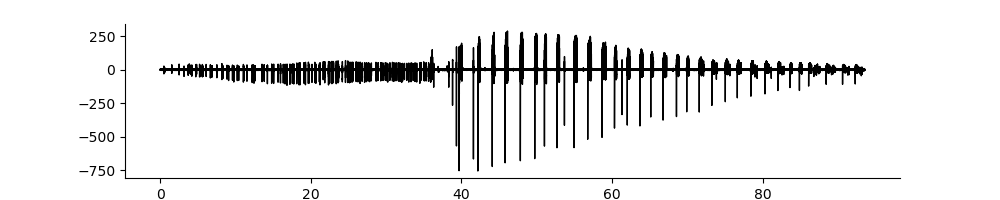

In [7]:
plt.figure(figsize = (10,2))
import matplotlib.patches as patches

#68,70,72,74,76,78
mv_scale_factor =  1000000
#141
plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate)/60,(filt[:,147]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='k'),#);
# plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate)/60,(filt[:,18]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='r'),#);
# plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate)/60,(filt[:,7]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='r'),#);
# plt.xlim(85,140.3)
plt.plot([2,3],[-.00005,-.00005],color='k')
# plt.text(2.,-.000062,'1min')
# blocks = [[2380,2410]]#[222,223],[1157,1158],
# blocks = [[44.3,44.45]]

# for block in na(blocks): 
#     plt.axvspan(block[0],block[1],color='k',alpha=0.2)
# rect1 = patches.Rectangle((2, 2), 4, 3, linewidth=2, edgecolor='red', facecolor='none')

# plt.plot([-1,-1],[-.00002,.0000],color='k')
# plt.text(-4.,-.0000,'1µV')
# plt.ylim([-5e-5,8e-5])
# plt.axis('off')
sns.despine()

# plt.savefig('../figs/MEA_hour.pdf')
plt.show()
# plt.ax

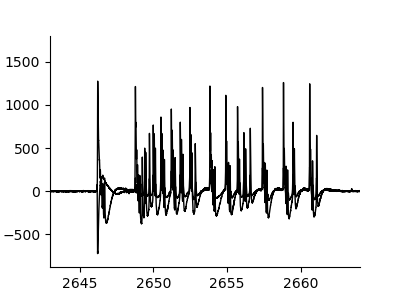

In [199]:
plt.figure(figsize = (4,3))
import matplotlib.patches as patches

#68,70,72,74,76,78
mv_scale_factor =  1000000
#141
plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate),(filt[:,147]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='k'),#);

# plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate),(filt[:,sel_ch]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='r'),#);
# plt.xlim(85,140.3)
plt.plot([2,3],[-.00005,-.00005],color='k')
# plt.xlim([47.8*60,48.3*60])
plt.xlim([44.05*60,44.4*60])
# plt.text(2.,-.000062,'1min')
# blocks = [[2380,2410]]#[222,223],[1157,1158],
# for block in na(blocks): 
#     plt.axvspan(block[0],block[1],color='k',alpha=0.2)
# rect1 = patches.Rectangle((2, 2), 4, 3, linewidth=2, edgecolor='red', facecolor='none')

# plt.plot([-1,-1],[-.00002,.0000],color='k')
# plt.text(-4.,-.0000,'1µV')
# plt.ylim([-5e-5,8e-5])
# plt.axis('off')
sns.despine()
plt.show()
plt.savefig('../figs/MEA_hour_zoom1.pdf')

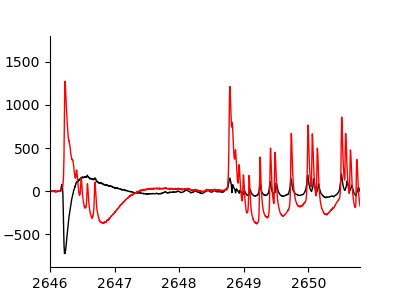

In [201]:
plt.figure(figsize = (4,3))
import matplotlib.patches as patches

#68,70,72,74,76,78
mv_scale_factor =  1000000
#141
plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate),(filt[:,147]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='k'),#);
plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate),(filt[:,128]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='r'),#);
# plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate),(filt[:,sel_ch]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='r'),#);
# plt.xlim(85,140.3)
plt.plot([2,3],[-.00005,-.00005],color='k')
# plt.xlim([47.8*60,47.9*60])
plt.xlim([44.1*60,44.18*60])
# plt.text(2.,-.000062,'1min')
# blocks = [[2380,2410]]#[222,223],[1157,1158],
# for block in na(blocks): 
#     plt.axvspan(block[0],block[1],color='k',alpha=0.2)
# rect1 = patches.Rectangle((2, 2), 4, 3, linewidth=2, edgecolor='red', facecolor='none')

# plt.plot([-1,-1],[-.00002,.0000],color='k')
# plt.text(-4.,-.0000,'1µV')
# plt.ylim([-5e-5,8e-5])
# plt.axis('off')
sns.despine()
plt.show()
# plt.savefig('../figs/MEA_hour_zoom2.pdf')

In [100]:
ind_mask = ((np.arange(0,len(filt[:]))*(1/subsampling_rate))>[47.8*60]) *((np.arange(0,len(filt[:]))*(1/subsampling_rate))<48.3*60)


In [102]:
nap

np.int64(23999)

(0.0, 29.997500000000002)

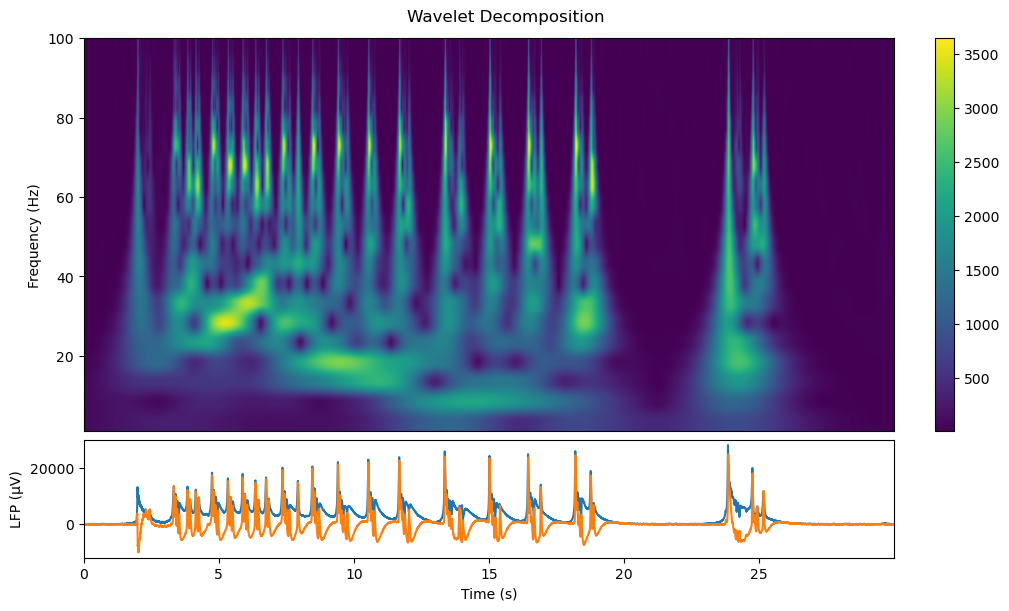

In [103]:
import pynapple as nap
# Define wavelet decomposition plotting function
def plot_timefrequency(freqs, powers, ax=None,t=None):
    t1,t2 = t
    im = ax.imshow(np.abs(powers), aspect="auto",extent = [t1,t2,np.max(freqs),np.min(freqs)])
    ax.invert_yaxis()
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.get_xaxis().set_visible(False)
    # ax.set(yticks=np.arange(len(freqs))[::2], yticklabels=np.rint(freqs[::2]))
    ax.grid(False)
    return im
    
fs = 1600
freqs = np.geomspace(1, 100,20)
ts = np.arange(0,len(filt[ind_mask,141].T))*(1/subsampling_rate)
nap_data = nap.Tsd(t =ts, d = filt[ind_mask,141],) 
cwt_rem = nap.compute_wavelet_transform(nap_data, fs=fs, freqs=freqs)

fig = plt.figure(constrained_layout=True, figsize=(10, 6))
fig.suptitle("Wavelet Decomposition")
gs = plt.GridSpec(2, 1, figure=fig, height_ratios=[1.0, 0.3])
ax0 = plt.subplot(gs[0, 0])

t1,t2= (np.min(ts),np.max(ts))
im = plot_timefrequency(freqs, np.transpose(cwt_rem[:, :].values), ax=ax0,t=(np.min(ts),np.max(ts)))
ax0.set_xlim(t1,t2)
cbar = fig.colorbar(im, ax=ax0, orientation="vertical")
ax1 = plt.subplot(gs[1, 0])
analytic_signal = scipy.signal.hilbert(nap_data)
envelope = np.abs(analytic_signal)
# ax1.plot(ts,envelope)
ax1.plot(nap_data)
ax1.set_ylabel("LFP (µV)")
ax1.set_xlabel("Time (s)")
ax1.set_xlim(t1,t2)
# ax1.margins(0)

In [115]:
data_band = nap.apply_bandpass_filter(nap_data, cutoff=(60, 100.0), fs=fs,mode='butter', order=4)
data_band2 = nap.apply_bandpass_filter(nap_data, cutoff=(4, 8.0), fs=fs,mode='butter', order=4)


(0.0, 5.0)

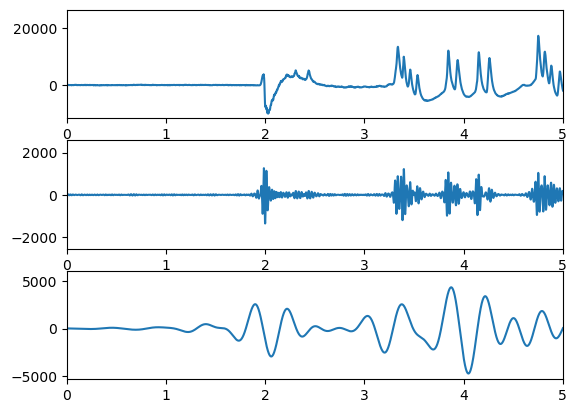

In [118]:
plt.figure()
plt.subplot(3,1,1)
plt.plot(nap_data)
plt.xlim([0,5])
plt.subplot(3,1,2)
plt.plot(data_band)
plt.xlim([0,5])
plt.subplot(3,1,3)
plt.plot(data_band2)
plt.xlim([0,5])

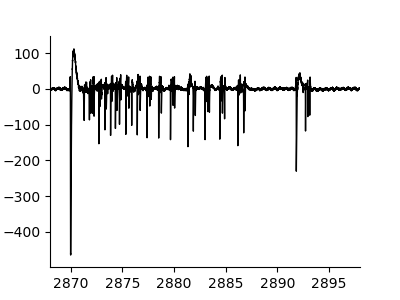

In [6]:
plt.figure(figsize = (4,3))
import matplotlib.patches as patches

#68,70,72,74,76,78
mv_scale_factor =  1000000
plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate),(filt[:,163]*adc_step)*mv_scale_factor,'-',linewidth = 1,color='k'),#);
# plt.xlim(85,140.3)
plt.plot([2,3],[-.00005,-.00005],color='k')
plt.xlim([47.8*60,48.3*60])
# plt.text(2.,-.000062,'1min')
# blocks = [[2380,2410]]#[222,223],[1157,1158],
# for block in na(blocks): 
#     plt.axvspan(block[0],block[1],color='k',alpha=0.2)
# rect1 = patches.Rectangle((2, 2), 4, 3, linewidth=2, edgecolor='red', facecolor='none')

# plt.plot([-1,-1],[-.00002,.0000],color='k')
# plt.text(-4.,-.0000,'1µV')
# plt.ylim([-5e-5,8e-5])
# plt.axis('off')
sns.despine()
plt.show()
# plt.savefig('../figs/MEA_hour_zoom1.pdf')

In [5]:
def generate_axes(fig):
    gridspec = fig.add_gridspec(nrows=2, ncols=12)
    axes = {}
    axes['1'] = fig.add_subplot(gridspec[0:2, 0:2])
    axes['2'] = fig.add_subplot(gridspec[0:2, 2:6])
    axes['3'] = fig.add_subplot(gridspec[0:2, 6:10])
    return axes



In [6]:
blocks = na(na([[26.01,26.09],[35.5,36.4],[65.1,66.6]])*(subsampling_rate)*60,dtype = 'int')# in s

NameError: name 'generate_axes' is not defined

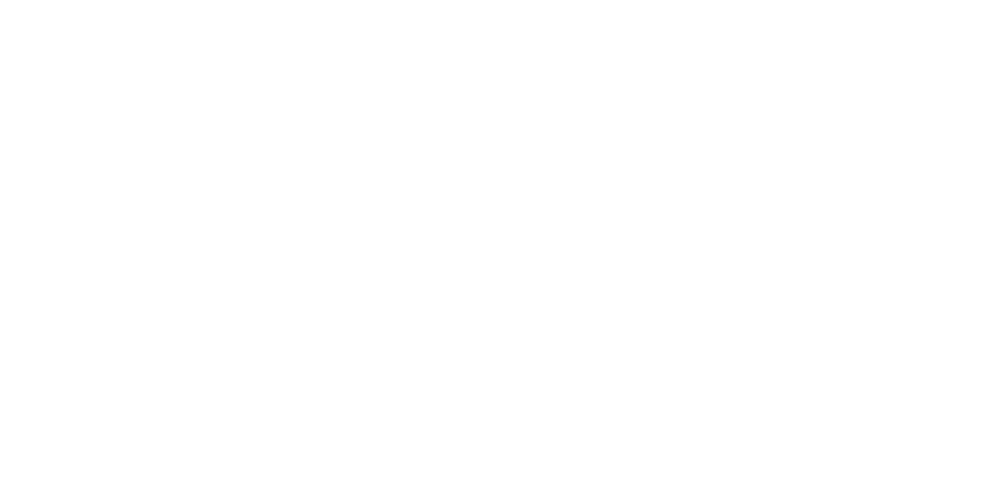

In [7]:
fig = plt.figure(figsize = (10,5))
axes = generate_axes(fig)
x_ax = [1,10,10]
x_ax_label = ['1s','10s','10s']
for i,time in enumerate(blocks):
    # plt.subplot(1,3,i+1)
    cut_out = filt[time[0]:time[1],20]*adc_step
    axes['%s'%(i+1)].plot(np.arange(0,len(cut_out))*(1/subsampling_rate),cut_out,'-k',linewidth = 1.);
    # plt.xlim(time[0],time[1])
    axes['%s'%(i+1)].set_ylim([-4e-5,3e-5])
    axes['%s'%(i+1)].plot([0,x_ax[i]],[-4e-5,-4e-5],color='k',linewidth = 5)
    axes['%s'%(i+1)].text(0.,-4.5e-5,x_ax_label[i])
    axes['%s'%(i+1)].axis('off')
plt.show()

In [7]:
ch_detection =pd.read_csv('/mnt/server_epl/SCN1A/R1648/21-3-25/slice6/stack/labeled_electrodes.csv')#['e_pos_x']
# y_pos = pd.read_csv('/mnt/server_epl/SCN1A/R1648/21-3-25/slice6/stack/labeled_electrodes.csv')['e_pos_y']

In [8]:
I = plt.imread('/mnt/server_epl/SCN1A/R1648/21-3-25/slice6/stack/Fused.tif')

In [9]:
import cv2
image = cv2.imread('/mnt/server_epl/SCN1A/R1648/21-3-25/slice6/stack/Fused.tif', cv2.IMREAD_UNCHANGED)
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [14]:
na(ch_detection['e_pos_x'],dtype=float)

array([1684.39885513, 1809.37806563, 1933.35808689, 2058.3372974 ,
       2182.31731866, 2307.29652917, 2431.27655043, 2556.25576094,
       1680.06853846, 1804.04855973, 1929.04119619, 2054.00698074,
       2178.00042796, 2302.97963846, 2426.95965973, 2551.93887023,
       2675.9188915 , 1799.73166902, 1924.71087953, 2048.69090079,
       2173.6701113 , 2298.66274776, 2422.64276903, 2547.60855357,
       2672.58776408, 2045.37319933, 2169.35322059, 2294.3324311 ,
       2418.31245236, 2543.29166287, 2668.27087337, 2792.25089464,
       2165.02290393, 2290.00211444, 2413.9821357 , 2538.96134621,
       2663.94055671, 2787.92057798, 2285.68522373, 2409.665245  ,
       2534.6444555 , 2659.62366601, 2783.60368727, 2907.58370854,
       2405.33492834, 2530.31413884, 2654.29416011, 2779.27337061,
       2903.25339188, 2525.99724814, 2649.9772694 , 2774.95647991,
       2898.93650117, 2645.64695274, 2770.62616324, 2894.60618451,
       2641.33006204, 2766.30927254, 2890.28929381, 2636.99974

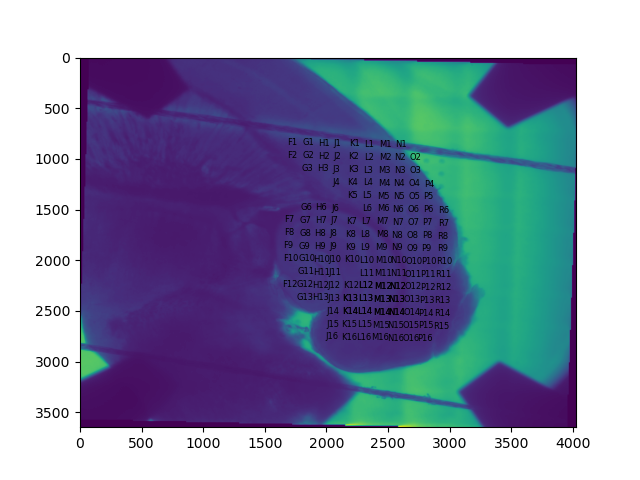

In [82]:
# %matplotlib inline
plt.close()
plt.figure()
plt.imshow(I,aspect='auto')
# plt.plot(ch_detection['e_pos_x']/100,ch_detection['e_pos_y']/100,'.r')
for i in range(len(ch_detection['e_pos_x'])):
    plt.text(x=na(ch_detection['e_pos_x'],dtype=float)[i],
             y=na(ch_detection['e_pos_y'],dtype=float)[i],
             s=na(ch_detection['e_label'],dtype=str)[i],fontsize=6);
#     # plt.text(x=k[0],y=k[1],s= ch_labels_m[i],color='r')#na(ch_detection['e_label'])
#     # plt.plot(coords[0,:],coords[1,:],'.');
plt.show()

In [79]:
# plt.figure()
# plt.imshow(I[::10,::10],cmap='gray')

In [ ]:
plt.figure()
plt.plot(ch_detection['e_pos_x'],ch_detection['e_pos_y'],'.')

Recording_0 <HDF5 group "/Data/Recording_0" (1 members)>


TypeError: 'NoneType' object is not subscriptable

In [52]:
channel_raw_data

NameError: name 'channel_raw_data' is not defined

In [24]:
#get channels 

# file_name = '/Users/ovinogradov/Documents/Projects/SCN1A/MEA-analysis/data/Shaima_example/2025-01-17T21-17-46McsRecording.h5'

# ['/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-15-02McsRecording.h5_filtered.h5',

# '/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-29-29McsRecording.h5_filtered.h5'
 
#  '/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-52-02McsRecording.h5_filtered.h5'
# ]

# target_file = '/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-52-02McsRecording.h5_filtered.h5'#/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-15-02McsRecording.h5_filtered.h5'
file_names = ['/mnt/server_epl/SCN1A/R1648H-export/20-3-25/slice2/2025-03-20T12-08-00McsRecording.h5',
'/mnt/server_epl/SCN1A/R1648H-export/21-3-25/slice6/2025-03-21T14-52-28McsRecording.h5',
          '/mnt/server_epl/SCN1A/R1648H-export/21-3-25/slice3/2025-03-21T12-42-43McsRecording.h5'   ]


for file_name in [file_names[-1]]:
    channel_raw_data = McsPy.McsData.RawData(file_name)    
    
    # list(channel_raw_data.recordings[0].segment_streams[0].segment_entity.keys())
    channels = []
    channels_dict ={}
    for i in list(channel_raw_data.recordings[0].analog_streams[0].channel_infos.keys()):
        channels.append(channel_raw_data.recordings[0].analog_streams[0].channel_infos[i].label)#.recordings[0].segment_streams[0].segment_entity.keys()
        channels_dict[i]= channel_raw_data.recordings[0].analog_streams[0].channel_infos[i].label
    print(channels[0:10])

Recording_0 <HDF5 group "/Data/Recording_0" (1 members)>
Stream_0 <HDF5 group "/Data/Recording_0/AnalogStream/Stream_0" (3 members)>
ChannelData <HDF5 dataset "ChannelData": shape (252, 39500000), type "<i4">
ChannelDataTimeStamps <HDF5 dataset "ChannelDataTimeStamps": shape (1, 3), type "<i8">
InfoChannel <HDF5 dataset "InfoChannel": shape (252,), type "|V108">
['H16', 'H10', 'H14', 'H12', 'G13', 'G15', 'F16', 'J10', 'F14', 'H11']


(array([127]),)

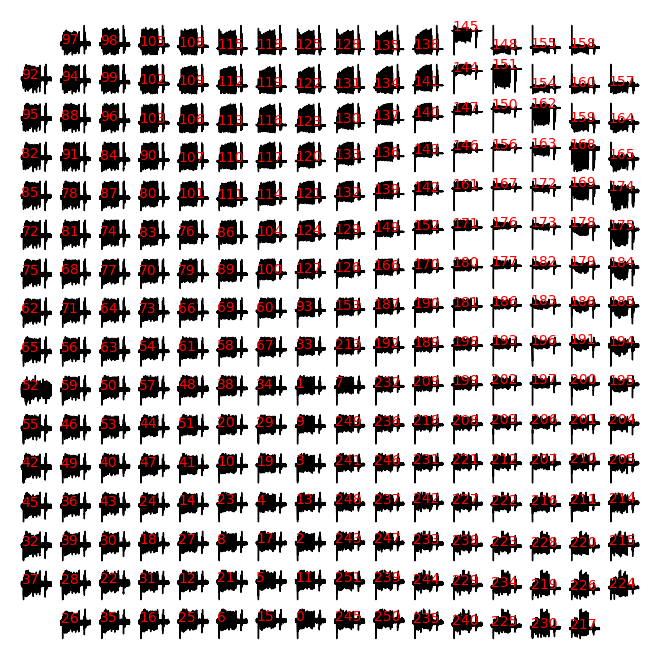

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a figure
def get_axes():
    fig, axs = plt.subplots(16, 16, figsize=(4, 4),dpi=200)
    letters = ['A','B','C','D','E','F','G','H','J','K','L','M','N','O','P','R']
    # Set the labels for each subplot
    labels = [[f"{letters[j]}{i + 1}" for j in range(16)] for i in range(16)]
    # Plot circles with text in each subplot
    ax_dict = {}
    for i in range(16):
        for j in range(16):
            ax = axs[i, j]
            ax.axis('off')
#             circle = patches.Circle((0.5, 0.5), radius=0.4,facecolor=[1,1,1],edgecolor='skyblue')#, color='skyblue')
#             ax.add_patch(circle)
            ax_dict[labels[i][j]] =ax
    return fig, ax_dict
    
fig,ax = get_axes()
# uids = list(file.recordings[0].segment_streams[0].segment_entity.keys())
na = np.array
time = blocks[0]
for uid,unit in enumerate((channels)):
    # label = file.recordings[0].segment_streams[0].segment_entity[unit].info.label
#     unit_label[] = unit
    # time[0]:time[1]
    tt = np.arange(0,len(filt[:]))*(1/subsampling_rate)/60

    mask = (tt>time[0])*(tt<time[1])
    # (int(time[0]*(subsampling_rate))):(int(time[1]*(subsampling_rate)))
    cut_out = filt[mask,uid]*adc_step*mv_scale_factor
    ax[unit].plot(cut_out,'-',linewidth = 0.5,color='k'),#);
    ax[unit].text(0,0,uid,fontsize=5,color='r')
    # ax[unit].text(0,0,unit,fontsize=5,color='r')
    # ax[unit].text(0,0,uid,fontsize=5,color='r')
    # if np.where(ch_detection['e_label']==unit)[0].size>0:
    #     ind = np.where(ch_detection['e_label']==unit)[0]
    #     # string = na(ch_detection['region'][ind])[0]
    #     ax[unit].text(0,0,string,fontsize=5)#file.recordings[0].segment_streams[0].segment_entity[unit].data,'-C5',alpha=0.4);
#     circle = patches.Circle((0.5, 0.5), radius=0.4,facecolor=[1,1,1],edgecolor='skyblue')#, color='skyblue')
#     ax[label].add_patch(circle)
#     ax[label].axis('off')
    # ax[unit].set_ylim([-1000,1000])

In [42]:
filt.shape

(4492000, 252)

(array([4.307558e+06, 5.726785e+06, 6.162390e+05, 1.892170e+05,
        4.487950e+05, 1.082132e+06, 2.130834e+06, 1.804400e+05,
        3.340000e+03, 1.508000e+03]),
 array([    0. ,  1336.1,  2672.2,  4008.3,  5344.4,  6680.5,  8016.6,
         9352.7, 10688.8, 12024.9, 13361. ]),
 <BarContainer object of 10 artists>)

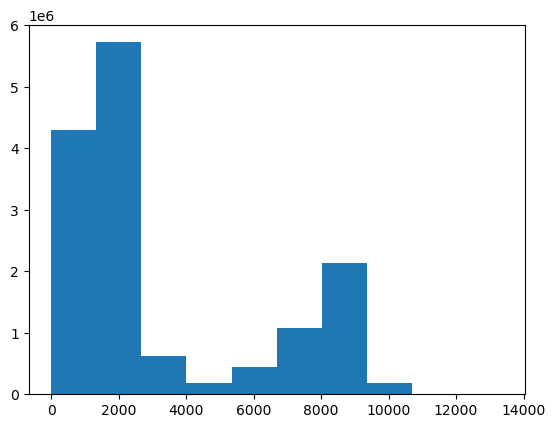

In [642]:
plt.hist(np.hstack(I))

In [93]:
chan_dict = {}
for i,l in enumerate(channels):
    chan_dict[l] = i

coords = np.vstack([ch_detection['e_pos_x'],ch_detection['e_pos_y']])
channel_mask = [chan_dict[i] for i in na(ch_detection['e_label'])]

_, unique_indices = np.unique(channel_mask, return_index=True)
channel_mask = na(channel_mask)[np.sort(unique_indices)]
coords = coords[:,np.sort(unique_indices)]

,Unnamed: 0,e_label,e_pos_x,e_pos_y,region,file
0,0,F1,1684.398855,862.836495,ctx,/Volumes/Epileptology01/Oleg/SCN1A/R1648/21-3-...
1,1,G1,1809.378066,865.879062,ctx,/Volumes/Epileptology01/Oleg/SCN1A/R1648/21-3-...
2,2,H1,1933.358087,868.946317,ctx,/Volumes/Epileptology01/Oleg/SCN1A/R1648/21-3-...
3,3,J1,2058.337297,871.988884,ctx,/Volumes/Epileptology01/Oleg/SCN1A/R1648/21-3-...
4,4,K1,2182.317319,875.056139,ctx,/Volumes/Epileptology01/Oleg/SCN1A/R1648/21-3-...
...,...,...,...,...,...,...
150,150,G12,1760.812523,2265.868495,DG,/Volumes/Epileptology01/Oleg/SCN1A/R1648/21-3-...
151,151,J12,2009.771755,2271.978317,DG,/Volumes/Epileptology01/Oleg/SCN1A/R1648/21-3-...
152,152,G13,1756.482206,2392.673732,DG,/Volumes/Epileptology01/Oleg/SCN1A/R1648/21-3-...
153,153,H13,1880.462228,2395.740986,DG,/Volumes/Epileptology01/Oleg/SCN1A/R1648/21-3-...


In [28]:
 ch_labels_m = na(ch_detection['e_label'])[unique_indices]

In [13]:
coordinates = []
for uid,unit in enumerate((channels)):
    # label = file.recordings[0].segment_streams[0].segment_entity[unit].info.label
#     unit_label[] = unit
    # time[0]:time[1]
    # cut_out = filt[int(time[0]*(subsampling_rate)):int(time[1]*(subsampling_rate)),uid]*adc_step*mv_scale_factor
    coordinates.append([ax[unit].get_position().x0,ax[unit].get_position().y0])

coordinates=na(coordinates)

NameError: name 'ax' is not defined

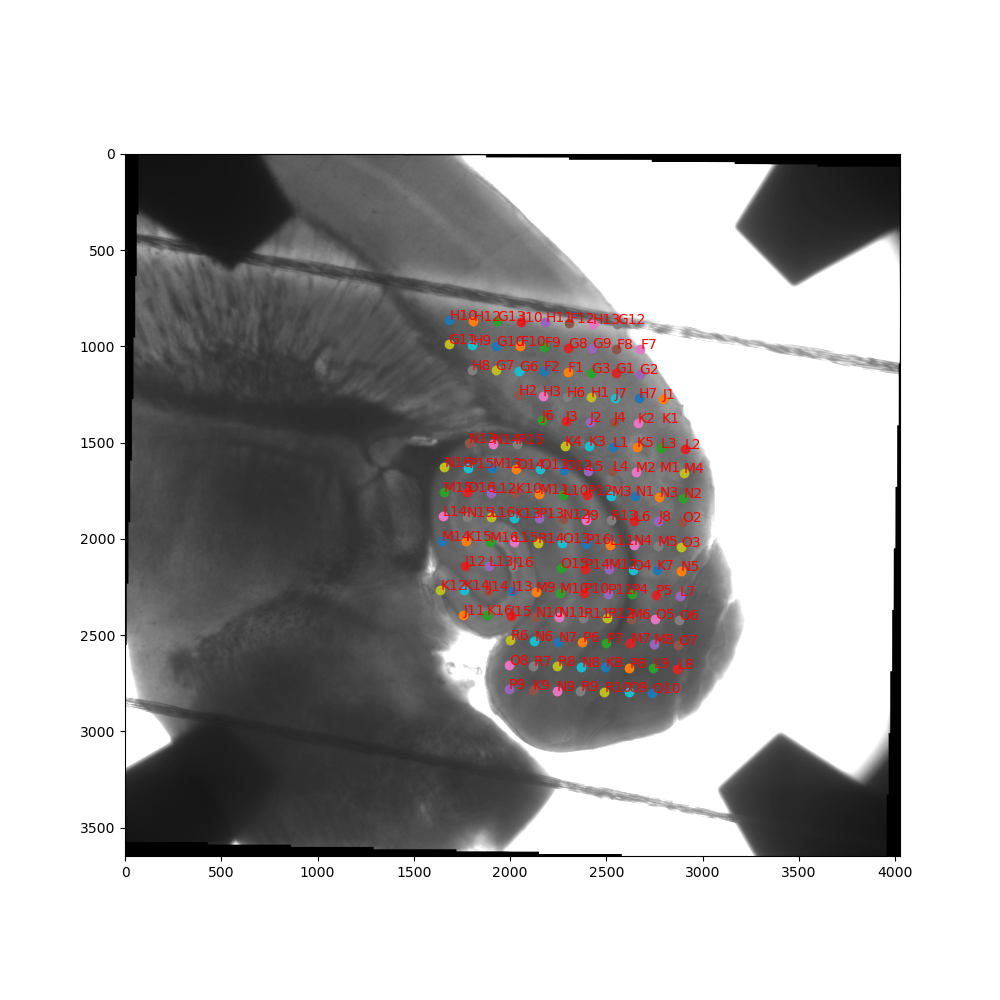

In [32]:
# coords = np.vstack([ch_detection['e_pos_x'],ch_detection['e_pos_y']])
# channel_mask = [chan_dict[i] for i in na(ch_detection['e_label'])]
plt.figure(figsize=(10,10))
plt.imshow(I[:,:],cmap='gray',vmax=5000)
for i,k in enumerate(coords.T):
    plt.plot(k[0],k[1],'o')
    plt.text(x=k[0],y=k[1],s= ch_labels_m[i],color='r')#na(ch_detection['e_label'])

In [177]:
mask = np.zeros(shape=(252),dtype=bool)
mask[:] = True
mask[52] = False

(252, 2)

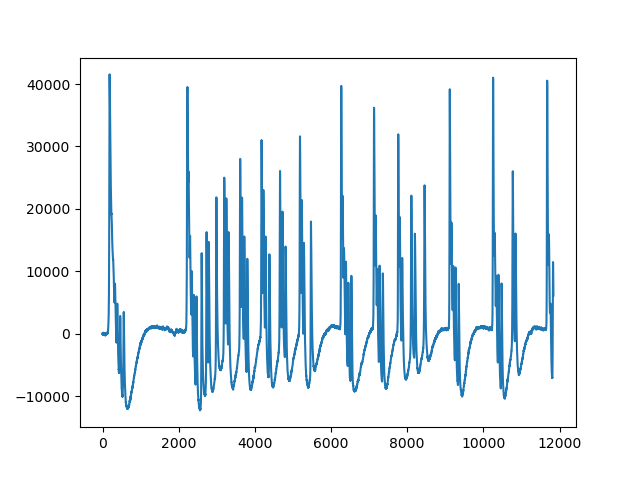

In [284]:
plt.figure()
# time = [44.1*60,44.18*60]
# time = ([44.1*60,44.18*60])
time=[2646.0, 2660.8]
plt.plot(filt[int(time[0]*(subsampling_rate)):int(time[1]*(subsampling_rate)),128])

In [204]:
from kcsd import KCSD2D

h =10  # distance between the electrode plane and the midslice
sigma = 1000. # S/m
# pots = pots.reshape((len(ele_pos), 1)) # first time point
data = filt[int(time[0]*(subsampling_rate)):int(time[1]*(subsampling_rate)),channel_mask].T*adc_step*mv_scale_factor
k = KCSD2D(coords.T, data[:,:],  h=h, sigma=sigma,#(data[mask,:].T/np.max(data[mask,:],1)).T#time_indices[0]:time_indices[-1]
           # xmin=0.0, xmax=1.0,
           # ymin=0.0, ymax=1.0,
           n_src_init=1000, src_type='gauss', R_init=100)
est_csd = k.values('CSD')

0      ctx
1      ctx
2      ctx
3      ctx
4      ctx
      ... 
150     DG
151     DG
152     DG
153     DG
154     DG
Name: region, Length: 155, dtype: object

In [227]:
ch_detection['region'].unique()

array(['ctx', 'ENT', 'SUB', 'CA1', 'CA3', 'DG'], dtype=object)

In [233]:
filt.shape

(4492000, 252)

In [236]:
4492000//10

449200

In [239]:
data.shape

(144,)

In [277]:
time=[2646.0, 2660.8]

In [282]:
2660.8- 2646.0

14.800000000000182

In [283]:
14.8/5

2.96

In [278]:
data = filt[int(time[0]*(subsampling_rate)):int(time[1]*(subsampling_rate)),channel_mask].T*adc_step*mv_scale_factor

In [279]:
np.sum(ch_detection['region']=='ctx')

np.int64(68)

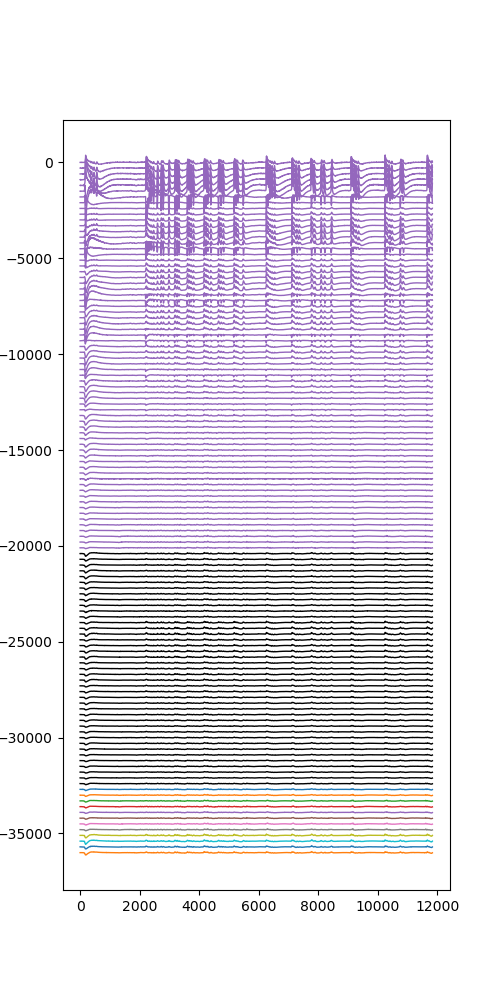

In [281]:
plt.figure(figsize=(5,10))
# colors = sns.color_palette("viridis", as_cmap=True,n_colors=)

# plt.subplot(1,3,1)
n = 0
for i,d in enumerate(data):
    if ch_detection['region'][i]=='ctx':
        # ch_detection['region'][i]
        plt.plot(d-n*300,'C4',lw=1)
        n+=1
        # plt.ylim(-69*200,500)
# plt.subplot(1,3,2)
for i,d in enumerate(data):
    if ch_detection['region'][i] in ['CA1', 'CA3', 'DG']:
        # ch_detection['region'][i]
        plt.plot(d-n*300,'k',lw=1)
        n+=1
        # plt.ylim(-69*200,500)

# plt.subplot(1,3,3)
for i,d in enumerate(data):
    if ch_detection['region'][i] in ['SUB']:
        # ch_detection['region'][i]
        plt.plot(d-n*300,lw=1)
        n+=1
        # plt.ylim(-69*200,500)
plt.savefig('../figs/MEA_regions.pdf')

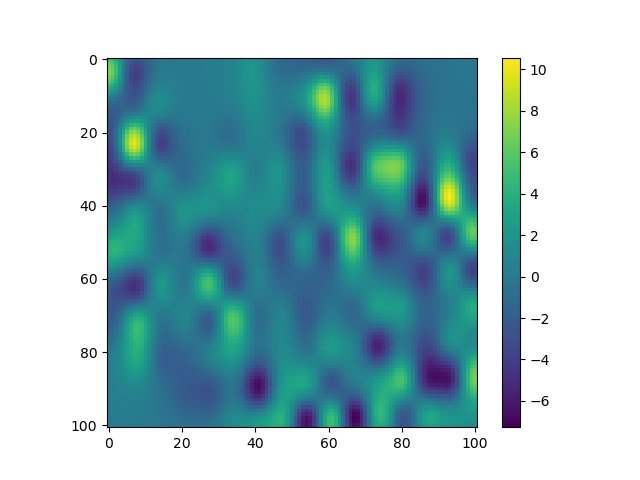

In [206]:
plt.figure()
plt.imshow(est_csd[:,:,20])
plt.colorbar()

In [296]:
k.cross_validate(Rs=np.linspace(0.01, 0.15, 15))
est_csd = k.values('CSD')

No lambda given, using defaults
Cross validating R (all lambda) : 0.01
Cross validating R (all lambda) : 0.019999999999999997
Cross validating R (all lambda) : 0.03
Cross validating R (all lambda) : 0.039999999999999994
Cross validating R (all lambda) : 0.049999999999999996
Cross validating R (all lambda) : 0.05999999999999999
Cross validating R (all lambda) : 0.06999999999999999
Cross validating R (all lambda) : 0.07999999999999999
Cross validating R (all lambda) : 0.08999999999999998
Cross validating R (all lambda) : 0.09999999999999998
Cross validating R (all lambda) : 0.10999999999999997
Cross validating R (all lambda) : 0.11999999999999998
Cross validating R (all lambda) : 0.12999999999999998
Cross validating R (all lambda) : 0.13999999999999999
Cross validating R (all lambda) : 0.15
R, lambda : 0.01 0.01


In [205]:
data[52,:] =np.nan
coordinates_= coordinates.copy
# coordinates_[]

In [166]:
coordinates[52,:] = np.nan

In [414]:
data = cut_out

In [34]:
import matplotlib.cm as cm

def make_plot(xx, yy, zz, title='True CSD', cmap=cm.bwr):
    fig = plt.figure(figsize=(7, 7))
    ax = plt.subplot(111)
    ax.set_aspect('equal')
    t_max = np.max(np.abs(zz))
    levels = np.linspace(-1 * t_max, t_max, 32)
    im = ax.contourf(xx, yy, zz, levels=levels, cmap=cmap)
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title(title)
    ticks = np.linspace(-1 * t_max, t_max, 3, endpoint=True)
    # plt.colorbar()
    return ax

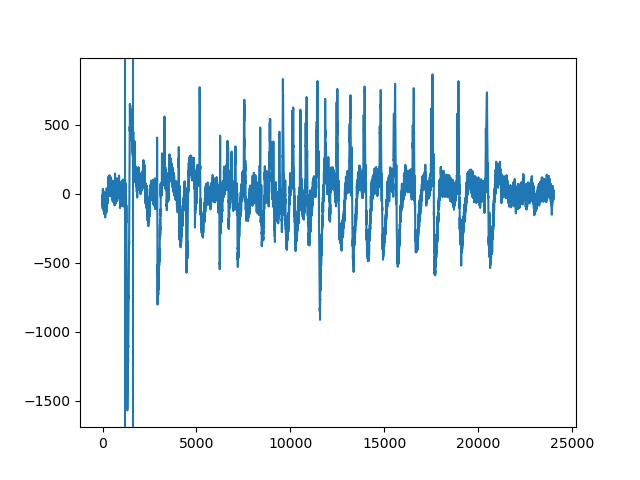

In [70]:
plt.figure()
plt.plot(filt[int(time[0]*(subsampling_rate)):int(time[1]*(subsampling_rate)),10].T)
plt.axvline(1200)
plt.axvline(1600)

In [37]:
coords = coordinates#np.random.rand(252, 2) * 10  # Replace with your real (252, 2) layout

t = 200
# ax = make_plot(k.estm_x, k.estm_y, est_csd[:, :, t],)
    # fig, ax = plt.subplots(figsize=(2, 2))
xx, yy, zz = k.estm_x, k.estm_y, est_csd[:, :, t]
fig = plt.figure(figsize=(7, 7))
ax = plt.subplot(111)
ax.set_aspect('equal')
t_max = np.max(np.abs(zz))
levels = np.linspace(-1 * t_max, t_max, 32)
im = ax.contourf(xx, yy, zz, levels=levels, cmap=cm.bwr,vmin=-500,vmax=500)
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
# ax.set_title(title)
# ax.set_color_bar()
plt.colorbar(im, orientation='horizontal', format='%.2f')

ticks = np.linspace(-1 * t_max, t_max, 3, endpoint=True)
ax.scatter(coords[:, 0], coords[:, 1], c=data[:, t], 
            cmap='bwr', vmin=-20, vmax=20, s=80)
ax.set_aspect('equal')
ax.set_title('Electrode Activity Over Time')
ax.axis('off')

NameError: name 'coordinates' is not defined

In [416]:
data.shape

(24000,)

In [187]:
%matplotlib inline
plt.figure()
# time_indices = np.linspace(1100, 1600 - 1, n_plots, dtype=int)
# time_indices = np.linspace(2500, 3000 - 1, n_plots, dtype=int)
# time_indices = np.linspace(5000, 5500 - 1, n_plots, dtype=int)
# time_indices = np.linspace(20370, 20500 - 1, n_plots, dtype=int)
n_plots=16
# time_indices = np.linspace(20340, 20500 - 1, n_plots, dtype=int)
# time_indices = np.linspace(1100, 22000 - 1, n_plots, dtype=int)
time_indices = np.linspace(20, 500 - 1, n_plots, dtype=int)
time_indices = np.linspace(520, 600 - 1, n_plots, dtype=int)
plt.plot(data[78,:]/data[78,:].max())
# plt.plot(data[223,:]/data[223,:].max())
plt.plot(data[22,:]/data[22,:].max())


# plt.plot(phase[138,:],'C0')
# # plt.plot(phase[223,:],'C1')|
# plt.plot(phase[33,:],'C2')
# plt.plot(band_filtered_data[138,:]/np.max(band_filtered_data[138,:]),'C0')
# plt.plot(band_filtered_data[223,:]/np.max(band_filtered_data[223,:]),'C1')

# plt.plot(phase[138,:],'C0')
# plt.plot(phase[223,:],'C1')
# plt.xlim([time_indices[0],time_indices[-1]])


# plt.axvline(1200)
for i, t in enumerate(time_indices):
    plt.axvline(t,alpha=0.2)
# plt.xlim([time_indices[0],time_indices[-1]])

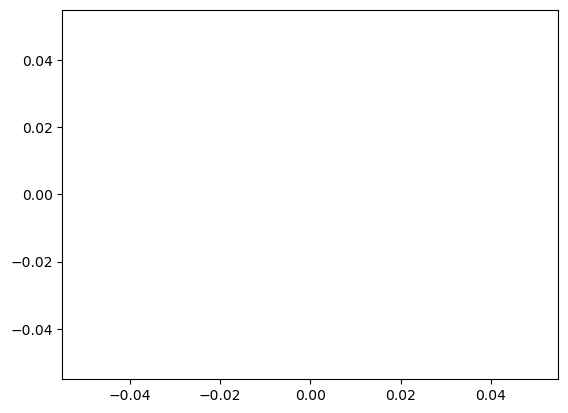

In [97]:
plt.plot(data[[66,33], time_indices[0]:time_indices[-1]].T,linewidth=5)


In [95]:
import matplotlib.pyplot as plt

latencies = compute_latency_map(data[:, :], window=[time_indices[0],time_indices[-1]], mode='peak')

plt.figure(figsize=(6, 6))
plt.imshow(I[:,:],cmap='gray',vmax=5000)

sc = plt.scatter(coords[0, :], coords[1,: ], c=latencies, cmap='spring', s=10,)#vmin=80,vmax=180)#(latencies*(1/subsampling_rate))*1000,
plt.colorbar(sc, label='Peak Latency (ms)')
plt.title("Peak Latency Map")
plt.axis('equal')
plt.axis('off')
# for i,c in enumerate(coords.T):
#     plt.text(c[0],c[1],i)

plt.show()

NameError: name 'time_indices' is not defined

(0.0, 0.99875)

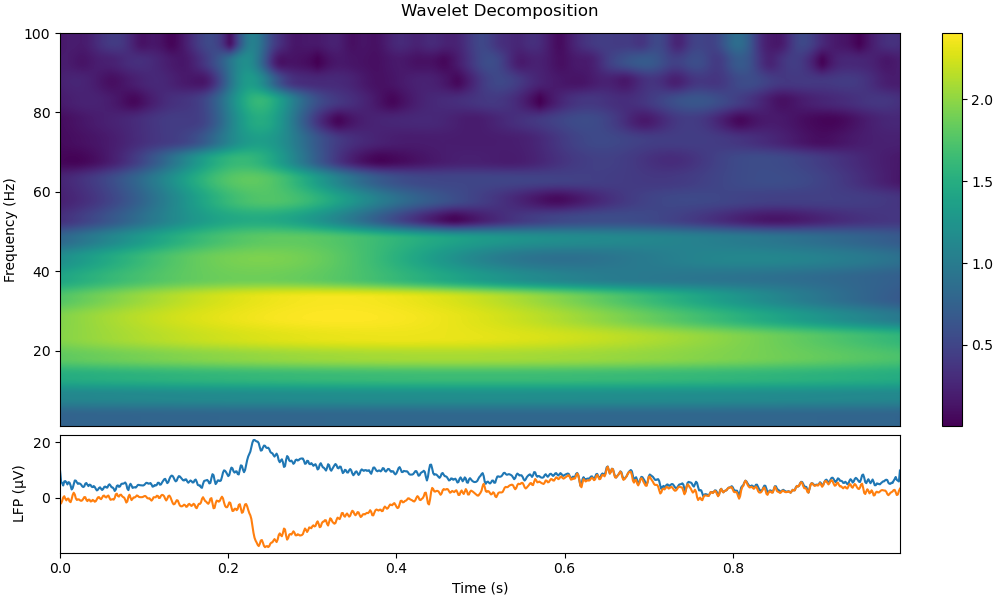

In [43]:
import pynapple as nap
# Define wavelet decomposition plotting function
def plot_timefrequency(freqs, powers, ax=None,t=None):
    t1,t2 = t
    im = ax.imshow(np.abs(powers), aspect="auto",extent = [t1,t2,np.max(freqs),np.min(freqs)])
    ax.invert_yaxis()
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.get_xaxis().set_visible(False)
    # ax.set(yticks=np.arange(len(freqs))[::2], yticklabels=np.rint(freqs[::2]))
    ax.grid(False)
    return im
    
fs = 1600
freqs = np.geomspace(1, 100,20)
ts = np.arange(0,len(data[138,:].T))*(1/subsampling_rate)
nap_data = nap.Tsd(t =ts, d = data[138,:].T,) 
cwt_rem = nap.compute_wavelet_transform(nap_data, fs=fs, freqs=freqs)

fig = plt.figure(constrained_layout=True, figsize=(10, 6))
fig.suptitle("Wavelet Decomposition")
gs = plt.GridSpec(2, 1, figure=fig, height_ratios=[1.0, 0.3])
ax0 = plt.subplot(gs[0, 0])

t1,t2= (np.min(ts),np.max(ts))
im = plot_timefrequency(freqs, np.transpose(cwt_rem[:, :].values), ax=ax0,t=(np.min(ts),np.max(ts)))
ax0.set_xlim(t1,t2)
cbar = fig.colorbar(im, ax=ax0, orientation="vertical")
ax1 = plt.subplot(gs[1, 0])
analytic_signal = scipy.signal.hilbert(nap_data)
envelope = np.abs(analytic_signal)
ax1.plot(ts,envelope)
ax1.plot(nap_data)
ax1.set_ylabel("LFP (µV)")
ax1.set_xlabel("Time (s)")
ax1.set_xlim(t1,t2)
# ax1.margins(0)

In [90]:
from scipy.signal import butter, sosfiltfilt,filtfilt

def bandpass_filter(data, fs, lowcut, highcut, order=4):
    b = butter(order, [lowcut / (fs), highcut / (fs)],
                 btype='band', output='sos')
    return sosfiltfilt(b, data, axis=1)


In [552]:
band_filtered_data= bandpass_filter(data[channel_mask,:],subsampling_rate,4,10)

In [553]:
fs

1600

(20270.0, 21499.0)

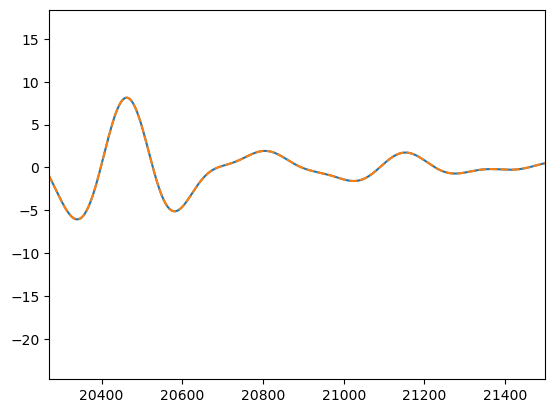

In [557]:
plt.plot(band_filtered_data[138,:])
nap_data = nap.Tsd(t =ts, d = data[channel_mask[138],:].T) 
data_band = nap.apply_bandpass_filter(nap_data, cutoff=(4, 10.0), fs=fs,mode='butter', order=4)
plt.plot(data_band.d,'--')
plt.xlim([time_indices[0],time_indices[-1]])


In [340]:
band_filtered_data.shape

(252, 24000)

In [560]:
analytic_signal = scipy.signal.hilbert(band_filtered_data,axis=1)
phase = np.angle(analytic_signal) 

(20270.0, 21499.0)

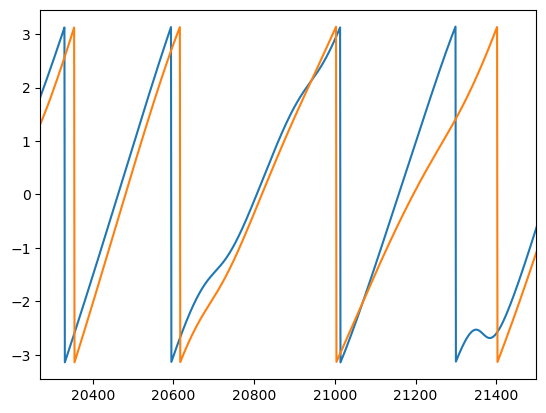

In [561]:
plt.plot(phase[138,:])
# plt.plot(phase[223,:])
plt.plot(phase[33,:])
plt.xlim([time_indices[0],time_indices[-1]])


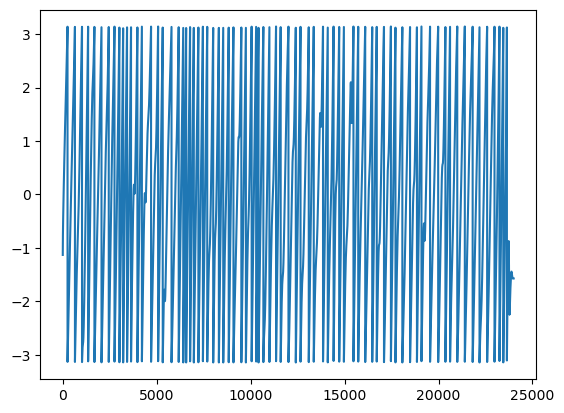

In [347]:
%matplotlib inline

plt.figure()
for i,ch in enumerate([138,223]):
    nap_data = nap.Tsd(t =ts, d = data[ch,:].T) 
    data_band = nap.apply_bandpass_filter(nap_data, cutoff=(4, 10.0), fs=fs,mode='butter', order=4)
    analytic_signal = scipy.signal.hilbert(data_band.d)
    phase = np.angle(analytic_signal)  # shape: (n_channels, n_timepoints)
    plt.plot(phase)#data_band.d/np.max(data_band.d))
    

# plt.plot(data[138,:].T*0.001,color='C0')
# plt.plot(10*data[223,:].T*0.01,color='C1')
#     # ax1.plot(data_band)
time_indices = np.linspace(18000, 20500 - 1, n_plots, dtype=int)
# plt.xlim([time_indices[0],time_indices[-1]])


In [45]:
fs = 1600
channel = 223
freqs = np.geomspace(1, 100,20)
ts = np.arange(0,len(data[channel,:].T))*(1/subsampling_rate)
nap_data = nap.Tsd(t =ts, d = data[channel,:].T,) 
cwt_rem = nap.compute_wavelet_transform(nap_data, fs=fs, freqs=freqs)

data_band = nap.apply_bandpass_filter(nap_data, cutoff=(4, 10.0), fs=fs,mode='butter', order=4)

fig = plt.figure(constrained_layout=True, figsize=(10, 6))
fig.suptitle("Wavelet Decomposition")
gs = plt.GridSpec(2, 1, figure=fig, height_ratios=[1.0, 0.3])
ax0 = plt.subplot(gs[0, 0])

t1,t2= (np.min(ts),np.max(ts))
im = plot_timefrequency(freqs, np.transpose(cwt_rem[:, :].values), ax=ax0,t=(np.min(ts),np.max(ts)))
ax0.set_xlim(t1,t2)
cbar = fig.colorbar(im, ax=ax0, orientation="vertical")
ax1 = plt.subplot(gs[1, 0])
# analytic_signal = scipy.signal.hilbert(nap_data)
# envelope = np.abs(analytic_signal)
# ax1.plot(ts,envelope)
ax1.plot(data_band)
ax1.set_ylabel("LFP (µV)")
ax1.set_xlabel("Time (s)")
ax1.set_xlim(t1,t2)
# ax1.margins(0)

NameError: name 'data' is not defined

In [185]:
time_indices

array([520, 525, 530, 535, 541, 546, 551, 556, 562, 567, 572, 577, 583,
       588, 593, 599])

In [ ]:
plt.plot(phase[138,:])
plt.plot(phase[223,:])

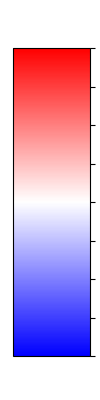

In [215]:

# Create a figure and a dummy image with bwr colormap
fig, ax = plt.subplots(figsize=(1, 4))

# Create a scalar mappable with a normalization and the bwr colormap
norm = plt.Normalize(vmin=-20, vmax=20)  # Set your desired range
sm = plt.cm.ScalarMappable(cmap=cm.bwr, norm=norm)
sm.set_array([])  # Required for ScalarMappable

# Add the colorbar
cbar = fig.colorbar(sm, cax=ax)
plt.savefig('../figs/CSD_colorbar.pdf')

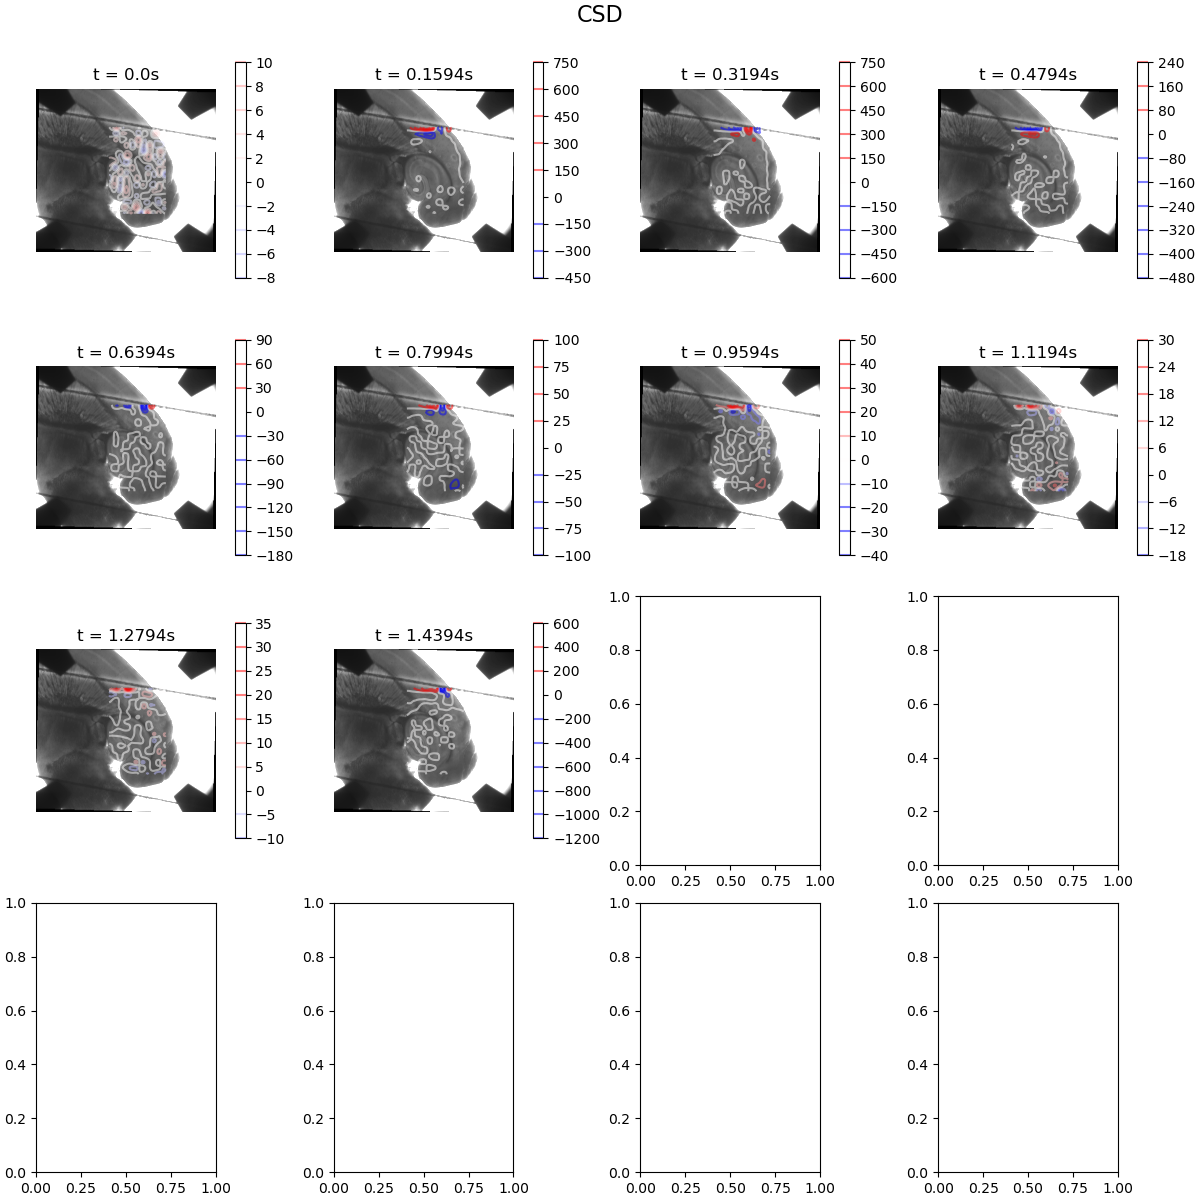

In [213]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 30 time points evenly spaced in your data
n_plots = 16
time_indices = np.linspace(0, est_csd.shape[2] - 1, n_plots, dtype=int)

# Create subplot grid
n_cols = 4
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, 
                         figsize=(n_cols * 3, n_rows * 3), constrained_layout=True)

# Get global max for consistent color scale
# csd_max = np.max(np.abs(est_csd))
# sc_max = np.max(np.abs(data))

for i, t in enumerate(time_indices[:10]):
    ax = axes.flat[i]
    zz = est_csd[:, :, t]
    levels = np.linspace(np.min(zz), np.max(zz), 15)
    
    # Contour plot of CSD
    im = ax.contour(k.estm_x, k.estm_y, zz, levels=levels, cmap=cm.bwr,alpha=0.5, vmin=-20, vmax=20)
    # Electrode scatter overlay
    # ax.scatter(coords[0, :], coords[1, :], c=data[channel_mask, t], cmap='bwr', 
    #            vmin=-100, vmax=100, s=10, edgecolor='k', linewidth=0.3,alpha=0.9)

    # ax.scatter(coords[0, :], coords[1, :], c=phase[:, t], cmap='bwr', 
    #            vmin=-1.5, vmax=1.5, s=10, edgecolor='k', linewidth=0.3,alpha=0.9)
    # # ax.scatter(coords[223, 0], coords[223, 1], c='k', cmap='bwr', vmin=-20, vmax=20, s=30, edgecolor='k', linewidth=0.3)
    ax.imshow(I[:,:],cmap='gray',vmax=5000)
    
    ax.set_title(f't = {round(t*(1/fs),4)}s')
    # ax.axis('off')
    ax.set_aspect('equal')
    ax.axis('off')
    plt.colorbar(im, ax=ax, orientation='vertical', shrink=0.8, pad=0.02)
# Hide any unused axes
# for ax in axes.flat[n_plots:]:
#     ax.axis('off')
# Add one colorbar for the whole figure
# cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])  # [left, bottom, width, height]
# fig.colorbar(im, cax=cbar_ax, orientation='horizontal', format='%.2f', label='CSD / μV/mm²')
plt.suptitle("CSD", fontsize=16)
plt.show()

In [139]:
# make_plot(k.estm_x, k.estm_y, est_csd[:, :, 15000],)
# 
import matplotlib.animation as animation
def make_video(k,data, coords, out_path='activity.mp4', fps=30):
    fig = plt.figure(figsize=(7, 7))
    ax = plt.subplot(111)
    ax.set_aspect('equal')
    t_max = np.max(np.abs(data[:,:,0]))
    levels = np.linspace(-1 * t_max, t_max, 32)
    im = ax.contourf(k.estm_x, k.estm_y, data[:,:,0], levels=levels, cmap=cm.bwr)
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    # ax.set_title(title)
    ticks = np.linspace(-1 * t_max, t_max, 3, endpoint=True)
    # Update function
    
    # Animation update
    def update(frame):
        # Safely remove previous contours
        for coll in ax.collections:
            coll.remove()
        new_contour = ax.contourf(k.estm_x, k.estm_y, data[:, :, frame], levels=levels, cmap=cm.bwr)
        return new_contour.collections

    ani = animation.FuncAnimation(
        fig, update, frames=data.shape[2], blit=True, interval=1000/fps
    )

    ani.save(out_path, fps=fps, dpi=200)
    plt.close()

# Usage
make_video(k, est_csd[:,:,:], coordinates, out_path='electrode_activityCSD.mp4')


NameError: name 'coordinates' is not defined

In [718]:
coords.shape

(2, 144)

(np.float64(-0.5), np.float64(4025.5), np.float64(3647.5), np.float64(-0.5))

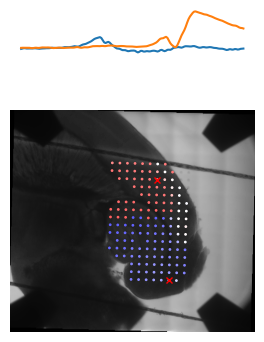

In [724]:
fig = plt.figure()
gridspec = fig.add_gridspec(nrows=7, ncols=12)
ax = {}
ax['a'] = fig.add_subplot(gridspec[0:1, 0:6])
ax['b'] = fig.add_subplot(gridspec[1:7, 0:6])

data_ = phase[:, time_indices[0]:time_indices[-1]:]
sc = ax['b'].scatter(coords.T[:, 0], coords.T[:, 1], c=data_[:, 0], 
            cmap='bwr', vmin=-5, vmax=5, s=1)
ax['b'].imshow(I[:,:],cmap='gray')
# data[138,:]/data[138,:].max()
ax['a'].plot(data[89, time_indices[0]:time_indices[-1]])
ax['a'].plot(data[22, time_indices[0]:time_indices[-1]])
ax['b'].plot(coords[ 0,[22,89]], coords[1,[22,89]],'xr',markersize = 5)
# ax[1].set_aspect('equal')
# ax[0].set_aspect('equal')
# ax.set_title('Electrode Activity Over Time')
ax['a'].axis('off')
ax['b'].axis('off')

CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1000x1000', '-pix_fmt', 'rgba', '-framerate', '30', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', 'electrode_activity.mp4']' returned non-zero exit status 255.

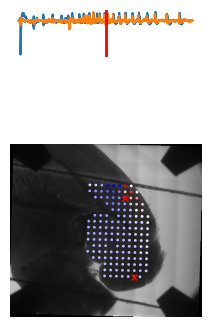

In [801]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
def make_video(data_,activity, coords, out_path='activity.mp4', fps=30):

    fig = plt.figure(figsize=(5, 5))
    gridspec = fig.add_gridspec(nrows=7, ncols=12)
    ax = {}
    ax['a'] = fig.add_subplot(gridspec[0:1, 0:6])
    ax['b'] = fig.add_subplot(gridspec[1:7, 0:6])
    
    # data_max = np.zeros(shape = (data_.shape[0])) 
    sc = ax['b'].scatter(coords[:, 0], coords[:, 1], c=data_[:, 0], 
                cmap='bwr', vmin=-70, vmax=70, s=1)
    ax['b'].plot(coords[[22,89], 0], coords[[22,89], 1],'xr',markersize = 5)

    
    
    ax['b'].imshow(I[:,:],cmap='gray')
    # data[138,:]/data[138,:].max()
    ax['a'].plot(activity/np.max(activity,0))

    ax['a'].axis('off')
    ax['b'].axis('off')
    time_marker = ax['a'].axvline(x=0, color='red', lw=2)
    def update(frame):
        data_max = np.zeros(shape = (data_.shape[0])) 

        # am = np.argmax(data_[:, frame])
        # data_max[am] = 5
        sc.set_array(data_[:, frame])
        time_marker.set_xdata([frame])
        data_max = np.zeros(shape = (data_.shape[0])) 

        return [sc,time_marker]

    ani = animation.FuncAnimation(
        fig, update, frames=data_.shape[1], blit=True, interval=1000/fps
    )

    ani.save(out_path, fps=fps, dpi=200)
    plt.close()

# Usage
# make_video(phase[channel_mask,time_indices[0]:time_indices[5]], data[[138,223], time_indices[0]:time_indices[5]].T,coords.T, out_path='electrode_activity.mp4')
make_video(data[:,time_indices[0]:time_indices[-1]], data[[22,89], time_indices[0]:time_indices[-1]].T,coords.T, out_path='electrode_activity.mp4')

In [800]:
time_indices

array([ 1100,  2493,  3886,  5279,  6673,  8066,  9459, 10852, 12246,
       13639, 15032, 16425, 17819, 19212, 20605, 21999])

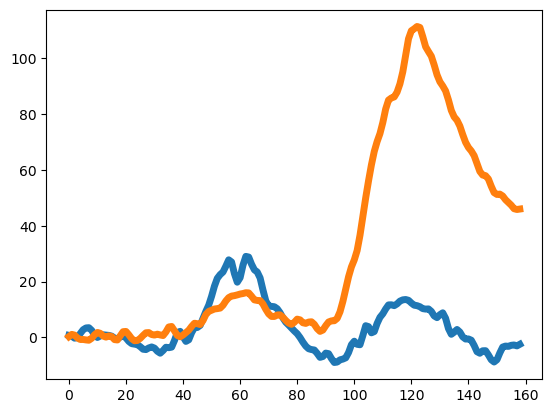

In [728]:
# plt.plot(data[:, time_indices[1]:time_indices[4]].T);
plt.plot(data[[66,33], time_indices[0]:time_indices[-1]].T,linewidth=5)
# plt.ylim([-20,20])

In [588]:
data.shape

(144, 24000)

(144, 159)


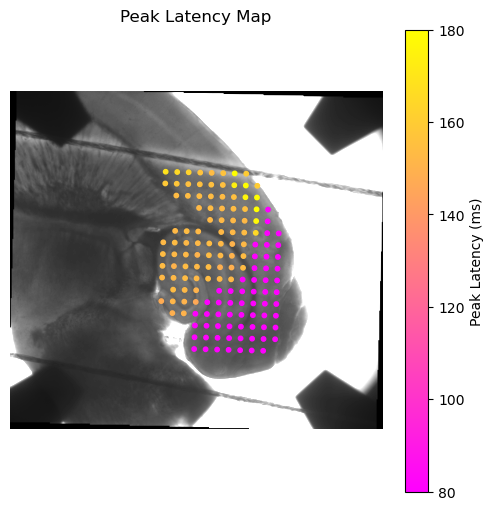

In [742]:
import matplotlib.pyplot as plt

latencies = compute_latency_map(data[:, :], window=[time_indices[0],time_indices[-1]], mode='peak')

plt.figure(figsize=(6, 6))
plt.imshow(I[:,:],cmap='gray',vmax=5000)

sc = plt.scatter(coords[0, :], coords[1,: ], c=(latencies*(1/subsampling_rate))*1000, cmap='spring', s=10,vmin=80,vmax=180)
plt.colorbar(sc, label='Peak Latency (ms)')
plt.title("Peak Latency Map")
plt.axis('equal')
plt.axis('off')
# for i,c in enumerate(coords.T):
#     plt.text(c[0],c[1],i)

plt.show()

In [ ]:
# import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.interpolate import griddata

def make_video(data, coords, out_path='activity.mp4', fps=30, timeseries_channel=138):

    # Interpolation grid
    grid_x, grid_y = np.mgrid[
        np.min(coords[:, 0]):np.max(coords[:, 0]):100j,
        np.min(coords[:, 1]):np.max(coords[:, 1]):100j
    ]
    
    # Create figure with two subplots: top = imshow, bottom = timeline
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7), gridspec_kw={'height_ratios': [4, 1]})
    plt.tight_layout()

    # Main activity plot (imshow)
    frame_0 = griddata(coords, data[:, 0], (grid_x, grid_y), method='cubic')
    im = ax1.imshow(frame_0.T, origin='lower', cmap='bwr',
                    extent=(grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()),
                    vmin=-100, vmax=100)
    ax1.set_title("Interpolated Electrode Activity")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")

    # Timeline plot
    ts = data[timeseries_channel, :]
    time_axis = np.arange(ts.shape[0])
    ax2.plot(time_axis, ts, color='gray', lw=1)
    time_marker = ax2.axvline(x=0, color='red', lw=2)
    ax2.set_xlim(0, len(ts))
    ax2.set_ylim(ts.min(), ts.max())
    ax2.set_ylabel(f"Ch {timeseries_channel}")
    ax2.set_xlabel("Time (frames)")

    # Animation update
    def update(frame):
        z = griddata(coords, data[:, frame], (grid_x, grid_y), method='cubic')
        im.set_data(z.T)
        # time_marker.set_xdata(frame)
        time_marker.set_xdata([frame])
        return [im, time_marker]

    ani = animation.FuncAnimation(
        fig, update, frames=data.shape[1], blit=True, interval=1000/fps
    )

    ani.save(out_path, fps=fps, dpi=200)
    plt.close()

# Example usage (replace with your actual values)
# make_video(data, coords, out_path='activity.mp4')
make_video(filt[int(time[0]*(subsampling_rate)):int(time[1]*(subsampling_rate)),:].T*adc_step*mv_scale_factor, coordinates, out_path='electrode_activity.mp4')

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Simulated example data
data = filt[int(time[0]*(subsampling_rate)):int(time[1]*(subsampling_rate)):100,:].T*adc_step*mv_scale_factor
coords = coordinates#np.random.rand(252, 2) * 10  # Replace with your real (252, 2) layout

# Create the figure and scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=data[:, 0], cmap='bwr', s=80,
                vmin=np.min(data), vmax=np.max(data))
ax.set_aspect('equal')
ax.set_title('Electrode Activity Over Time')
ax.axis('off')

# Animation update function
def update(frame):
    sc.set_array(data[:, frame])
    return sc,

# Create animation
ani = animation.FuncAnimation(
    fig, update, frames=data.shape[1], interval=20, blit=True

    ываы
)

# Display inline in Jupyter
HTML(ani.to_jshtml())

SyntaxError: invalid syntax (1477873495.py, line 27)

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

data = filt[int(time[0]*(subsampling_rate)):int(time[1]*(subsampling_rate)):20,:].T*adc_step*mv_scale_factor
coords = coordinates#np.random.rand(252, 2) * 10  # Replace with your real (252, 2) layout


# Interpolation grid
grid_x, grid_y = np.mgrid[
    np.min(coords[:, 0]):np.max(coords[:, 0]):100j,
    np.min(coords[:, 1]):np.max(coords[:, 1]):100j
]

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))
frame_0 = griddata(coords, data[:, 0], (grid_x, grid_y), method='cubic')
im = ax.imshow(frame_0.T, origin='lower', cmap='bwr',
               extent=(grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()),
               vmin=-100, vmax=100)

ax.set_title("Interpolated Electrode Activity")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# Animation update
def update(frame):
    z = griddata(coords, data[:, frame], (grid_x, grid_y), method='cubic')
    im.set_data(z.T)
    return [im]

ani = FuncAnimation(fig, update, frames=data.shape[1], interval=20, blit=True ываы)
HTML(ani.to_jshtml())

SyntaxError: invalid syntax (1933637750.py, line 34)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
def make_video(data, coords, out_path='activity.mp4', fps=30):

    # Interpolation grid
    grid_x, grid_y = np.mgrid[
        np.min(coords[:, 0]):np.max(coords[:, 0]):100j,
        np.min(coords[:, 1]):np.max(coords[:, 1]):100j
    ]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(6, 6))
    frame_0 = griddata(coords, data[:, 0], (grid_x, grid_y), method='cubic')
    im = ax.imshow(frame_0.T, origin='lower', cmap='bwr',
                   extent=(grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()),
                   vmin=-4, vmax=4)
    
    ax.set_title("Interpolated Electrode Activity")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    
    # Animation update
    def update(frame):
        z = griddata(coords, data[:, frame], (grid_x, grid_y), method='cubic')
        im.set_data(z.T)
        return [im]

    ani = animation.FuncAnimation(
        fig, update, frames=data.shape[1], blit=True, interval=1000/fps
    )

    ani.save(out_path, fps=fps, dpi=200)
    plt.close()

# Usage
make_video(filt[int(time[0]*(subsampling_rate)):int(time[1]*(subsampling_rate)):100,:].T*adc_step*mv_scale_factor, coordinates, out_path='electrode_activity.mp4')